In [1]:
import os
os.environ['JAX_ENABLE_X64'] = '1'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.1' 

%matplotlib inline
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

import numpy as np
from temgym_core.components import Detector
from temgym_core.run import run_to_end
from temgym_core.source import circular_input_wave
from temgym_core.evaluate import (
    evaluate_gaussians_gpu_kernel_wrapper,
    evaluate_gaussians_for,
    evaluate_gaussians_jax_scan
)

from temgym_core.utils import FresnelPropagator

jax.config.update("jax_enable_x64", True)


W0311 16:16:13.046306   36572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.


In [2]:
W = 10e-6  # Width of the simulation cell in nm

Nx = Ny = 256
center_idx = Nx // 2
dx = W/Nx
dy = W/Ny
grid = Detector(z=1e-1, pixel_size=(dx, dy), shape=(Nx, Ny))
coords = grid.coords
X, Y = coords[:,0].reshape(grid.shape), coords[:,1].reshape(grid.shape)
x, y = X[0,:], Y[:,0]
extent = (x[0], x[-1], y[0], y[-1])

voltage = 100e3  # in volts
components = (grid,)

W0311 16:16:14.224854   36572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0311 16:16:14.260958   36572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0311 16:16:14.293960   36572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0311 16:16:14.326914   36572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0311 16:16:14.349702   36572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0311 16:16:14.384726   36572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0311 16:16:14.418138   36572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0311 16:16:14.437806   36572 sol_gpu_cost_model

In [3]:
rays_in = circular_input_wave(
    voltage=voltage,
    aperture_radius=W/4,
    waist=2e-8
)
print(rays_in.x.size)
rays_in = rays_in.to_vector()

# Create JIT-ed single-ray and VMAP-ed batched versions without overwriting the original
run_to_end_jit = jax.jit(run_to_end)
run_to_end_vmapped = jax.jit(
    jax.vmap(run_to_end_jit, in_axes=(0, None)),
    static_argnums=(1,),
)


W0311 16:16:15.567013   36572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0311 16:16:15.612342   36572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0311 16:16:15.649171   36572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0311 16:16:15.686243   36572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0311 16:16:15.719208   36572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0311 16:16:15.752708   36572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0311 16:16:15.785812   36572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0311 16:16:15.823577   36572 sol_gpu_cost_model

196350


W0311 16:16:16.414457   36572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0311 16:16:16.434586   36572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0311 16:16:16.454259   36572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0311 16:16:16.473906   36572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0311 16:16:16.492931   36572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.


In [4]:
# %%timeit
# E_in_gpu = evaluate_gaussians_gpu_kernel_wrapper(rays_in, grid).block_until_ready()

In [5]:
def ensure_batch(x, sample_shape=(), dtype=None):
    """
    Ensure x has shape (B, *sample_shape), collapsing any existing leading dims into
    a batch dimension. If sample_shape == (), treat x as per-beam scalars and ensure
    shape (B,).

    Args:
        x: array-like
        sample_shape: tuple, the desired trailing shape
        dtype: optional dtype conversion

    Returns:
        JAX array with leading batch axis.
    """
    x = jnp.asarray(x, dtype=dtype)
    sample_shape = tuple(sample_shape)

    # Scalar case → produce (B,)
    if len(sample_shape) == 0:
        if x.ndim == 0:
            return x[None]           # scalar → (1,)
        if x.ndim == 1:
            return x                 # already (B,)
        return x.reshape((-1,))      # collapse all dims → (B,)

    # Non-scalar case
    s = len(sample_shape)

    # If trailing dims already match sample_shape → collapse leading dims to batch
    if x.ndim >= s and tuple(x.shape[-s:]) == sample_shape:
        return x.reshape((-1,) + sample_shape)

    # Exact match to sample_shape → add leading batch axis
    if tuple(x.shape) == sample_shape:
        return x[None, ...]

    # Fallback: add leading axis
    return x[None, ...]


def _prepare_gaussian_params(gaussian_ray):
    r = ensure_batch(gaussian_ray.r_xy, (2,), jnp.float64)
    dr = ensure_batch(gaussian_ray.d_xy, (2,), jnp.float64)
    amplitude = ensure_batch(gaussian_ray.amplitude, (), jnp.complex128)
    pathlength = ensure_batch(gaussian_ray.pathlength, (), jnp.float64)
    Q_inv = ensure_batch(gaussian_ray.Q_inv,  (2, 2), jnp.complex128)
    k = ensure_batch(gaussian_ray.k, (), jnp.float64)

    return r, dr, amplitude, pathlength, Q_inv, k

r, dr, amp, pathlength, Q_inv, k = _prepare_gaussian_params(rays_in)
r2 = grid.coords
n = r.shape[0]
total_field = jnp.zeros((r2.shape[0],), dtype=jnp.complex128)


W0311 16:16:16.526355   36572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0311 16:16:16.547054   36572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0311 16:16:16.567646   36572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0311 16:16:16.614544   36572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.


W0311 16:16:16.634290   36572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.


In [6]:
import math
import time
from numba import cuda
import numpy as np


@cuda.jit(cache=True)
def _beam_field_cuda(x_det, y_det, r, dr, amp, pl, Qi_r, Qi_i, k, out_r, out_i):
    beam_idx, pix_idx = cuda.grid(2)

    if beam_idx >= r.shape[0] or pix_idx >= x_det.size:
        return

    dx = x_det[pix_idx] - r[beam_idx, 0]
    dy = y_det[pix_idx] - r[beam_idx, 1]

    linear = dx * dr[beam_idx, 0] + dy * dr[beam_idx, 1]

    quad_r = (
        Qi_r[beam_idx, 0, 0] * dx * dx
        + (Qi_r[beam_idx, 0, 1] + Qi_r[beam_idx, 1, 0]) * dx * dy
        + Qi_r[beam_idx, 1, 1] * dy * dy
    )
    quad_i = (
        Qi_i[beam_idx, 0, 0] * dx * dx
        + (Qi_i[beam_idx, 0, 1] + Qi_i[beam_idx, 1, 0]) * dx * dy
        + Qi_i[beam_idx, 1, 1] * dy * dy
    )

    s_real = pl[beam_idx] + linear + 0.5 * quad_r
    s_imag = 0.5 * quad_i

    phase = k[beam_idx] * s_real
    atten = math.exp(-k[beam_idx] * s_imag)
    c = math.cos(phase)
    s = math.sin(phase)

    ar = amp[beam_idx].real
    ai = amp[beam_idx].imag

    cuda.atomic.add(out_r, pix_idx, atten * (ar * c - ai * s))
    cuda.atomic.add(out_i, pix_idx, atten * (ar * s + ai * c))


def evaluate_gaussians_cuda_gpu_kernel_wrapper(gaussian_ray, grid, tpb_beam=4, tpb_pix=128):
    r, dr, amp, pl, Q_inv, k = _prepare_gaussian_params(gaussian_ray)

    x_det = np.ascontiguousarray(grid.coords[:, 0], dtype=np.float64)
    y_det = np.ascontiguousarray(grid.coords[:, 1], dtype=np.float64)

    n_beams = r.shape[0]
    n_pix = x_det.size

    Qi = np.asarray(Q_inv, dtype=np.complex128)

    d_x = cuda.to_device(x_det)
    d_y = cuda.to_device(y_det)
    d_r = cuda.to_device(np.asarray(r, dtype=np.float64))
    d_dr = cuda.to_device(np.asarray(dr, dtype=np.float64))
    d_amp = cuda.to_device(np.asarray(amp, dtype=np.complex128))
    d_pl = cuda.to_device(np.asarray(pl, dtype=np.float64))
    d_Qi_r = cuda.to_device(np.ascontiguousarray(Qi.real, dtype=np.float64))
    d_Qi_i = cuda.to_device(np.ascontiguousarray(Qi.imag, dtype=np.float64))
    d_k = cuda.to_device(np.asarray(k, dtype=np.float64))

    d_out_r = cuda.device_array(n_pix, dtype=np.float64)
    d_out_i = cuda.device_array(n_pix, dtype=np.float64)
    d_out_r[:] = 0.0
    d_out_i[:] = 0.0

    blocks = (math.ceil(n_beams / tpb_beam), math.ceil(n_pix / tpb_pix))
    _beam_field_cuda[blocks, (tpb_beam, tpb_pix)](
        d_x, d_y, d_r, d_dr, d_amp, d_pl, d_Qi_r, d_Qi_i, d_k, d_out_r, d_out_i
    )

    return (d_out_r.copy_to_host() + 1j * d_out_i.copy_to_host()).reshape(grid.shape)

In [7]:

import numba

# Block dims are compile-time constants so cuda.shared.array can use them
_OPT_TPB_BEAM = 4
_OPT_TPB_PIX  = 64


@cuda.jit(cache=True, fastmath=True)
def _beam_field_cuda_opt(x_det, y_det, r, dr, amp, pl, Qi_r, Qi_i, k, out_r, out_i):
    beam_idx, pix_idx = cuda.grid(2)
    loc_beam = cuda.threadIdx.x
    loc_pix  = cuda.threadIdx.y

    # Each thread writes its contribution into shared memory —
    # one reduce-then-atomic per pixel per block instead of tpb_beam atomics.
    sh_r = cuda.shared.array((_OPT_TPB_BEAM, _OPT_TPB_PIX), dtype=numba.float32)
    sh_i = cuda.shared.array((_OPT_TPB_BEAM, _OPT_TPB_PIX), dtype=numba.float32)
    sh_r[loc_beam, loc_pix] = 0.0
    sh_i[loc_beam, loc_pix] = 0.0
    cuda.syncthreads()

    if beam_idx < r.shape[0] and pix_idx < x_det.size:
        dx = x_det[pix_idx] - r[beam_idx, 0]
        dy = y_det[pix_idx] - r[beam_idx, 1]

        linear = dx * dr[beam_idx, 0] + dy * dr[beam_idx, 1]

        quad_r = (
            Qi_r[beam_idx, 0, 0] * dx * dx
            + (Qi_r[beam_idx, 0, 1] + Qi_r[beam_idx, 1, 0]) * dx * dy
            + Qi_r[beam_idx, 1, 1] * dy * dy
        )
        quad_i = (
            Qi_i[beam_idx, 0, 0] * dx * dx
            + (Qi_i[beam_idx, 0, 1] + Qi_i[beam_idx, 1, 0]) * dx * dy
            + Qi_i[beam_idx, 1, 1] * dy * dy
        )

        s_real = pl[beam_idx] + linear + 0.5 * quad_r
        s_imag = 0.5 * quad_i

        phase = k[beam_idx] * s_real
        atten = math.exp(-k[beam_idx] * s_imag)
        c = math.cos(phase)
        s = math.sin(phase)

        ar = amp[beam_idx].real
        ai = amp[beam_idx].imag

        sh_r[loc_beam, loc_pix] = atten * (ar * c - ai * s)
        sh_i[loc_beam, loc_pix] = atten * (ar * s + ai * c)

    cuda.syncthreads()

    # One thread per pixel reduces the beam dimension → one global atomic per block per pixel
    if loc_beam == 0 and pix_idx < x_det.size:
        acc_r = 0.0
        acc_i = 0.0
        for b in range(_OPT_TPB_BEAM):
            acc_r += sh_r[b, loc_pix]
            acc_i += sh_i[b, loc_pix]
        cuda.atomic.add(out_r, pix_idx, acc_r)
        cuda.atomic.add(out_i, pix_idx, acc_i)


def evaluate_gaussians_cuda_gpu_kernel_wrapper_opt(gaussian_ray, grid):
    r, dr, amp, pl, Q_inv, k = _prepare_gaussian_params(gaussian_ray)

    x_det = np.ascontiguousarray(grid.coords[:, 0], dtype=np.float32)
    y_det = np.ascontiguousarray(grid.coords[:, 1], dtype=np.float32)

    n_beams = r.shape[0]
    n_pix   = x_det.size

    Qi = np.asarray(Q_inv, dtype=np.complex64)

    d_x    = cuda.to_device(x_det)
    d_y    = cuda.to_device(y_det)
    d_r    = cuda.to_device(np.asarray(r,   dtype=np.float32))
    d_dr   = cuda.to_device(np.asarray(dr,  dtype=np.float32))
    d_amp  = cuda.to_device(np.asarray(amp, dtype=np.complex64))
    d_pl   = cuda.to_device(np.asarray(pl,  dtype=np.float32))
    d_Qi_r = cuda.to_device(np.ascontiguousarray(Qi.real, dtype=np.float32))
    d_Qi_i = cuda.to_device(np.ascontiguousarray(Qi.imag, dtype=np.float32))
    d_k    = cuda.to_device(np.asarray(k,   dtype=np.float32))

    d_out_r = cuda.device_array(n_pix, dtype=np.float32)
    d_out_i = cuda.device_array(n_pix, dtype=np.float32)
    d_out_r[:] = 0.0
    d_out_i[:] = 0.0

    blocks = (math.ceil(n_beams / _OPT_TPB_BEAM), math.ceil(n_pix / _OPT_TPB_PIX))
    _beam_field_cuda_opt[blocks, (_OPT_TPB_BEAM, _OPT_TPB_PIX)](
        d_x, d_y, d_r, d_dr, d_amp, d_pl, d_Qi_r, d_Qi_i, d_k, d_out_r, d_out_i
    )

    return (d_out_r.copy_to_host() + 1j * d_out_i.copy_to_host()).reshape(grid.shape)


In [8]:
# Benchmark (warm up first)
evaluate_gaussians_cuda_gpu_kernel_wrapper(rays_in, grid, tpb_beam=4, tpb_pix=64)
evaluate_gaussians_cuda_gpu_kernel_wrapper_opt(rays_in, grid)

print("\nOriginal (global atomics):")
%timeit evaluate_gaussians_cuda_gpu_kernel_wrapper(rays_in, grid, tpb_beam=4, tpb_pix=64)
print("Optimised (shared-mem reduction + fastmath):")
%timeit evaluate_gaussians_cuda_gpu_kernel_wrapper_opt(rays_in, grid)


/Users/landers/.conda/envs/temgym/lib/python3.14/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/Users/landers/.conda/envs/temgym/lib/python3.14/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))



Original (global atomics):
1.91 s ± 316 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
Optimised (shared-mem reduction + fastmath):
347 ms ± 437 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [9]:
E_in_jax = evaluate_gaussians_gpu_kernel_wrapper(rays_in, grid).block_until_ready()
%timeit evaluate_gaussians_gpu_kernel_wrapper(rays_in, grid).block_until_ready()

W0311 16:16:37.354062   36572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0311 16:16:37.537984   36572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.


192 ms ± 90.3 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [10]:
# %%timeit
# E_in_scan = evaluate_gaussians_jax_scan(rays_in, grid)

In [11]:
rays_out = run_to_end_vmapped(rays_in, components)
E_prop = evaluate_gaussians_gpu_kernel_wrapper(rays_out, grid)

W0311 16:16:53.358104   36867 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0311 16:16:53.413043   36572 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.


In [12]:
E_prop = evaluate_gaussians_gpu_kernel_wrapper(rays_in, grid).block_until_ready()
%timeit evaluate_gaussians_gpu_kernel_wrapper(rays_in, grid).block_until_ready()

192 ms ± 72.3 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [13]:
fresnel_diffraction_pattern = FresnelPropagator(E_in, W, wavelength=rays_in[0].wavelength, z=grid.z)

NameError: name 'E_in' is not defined

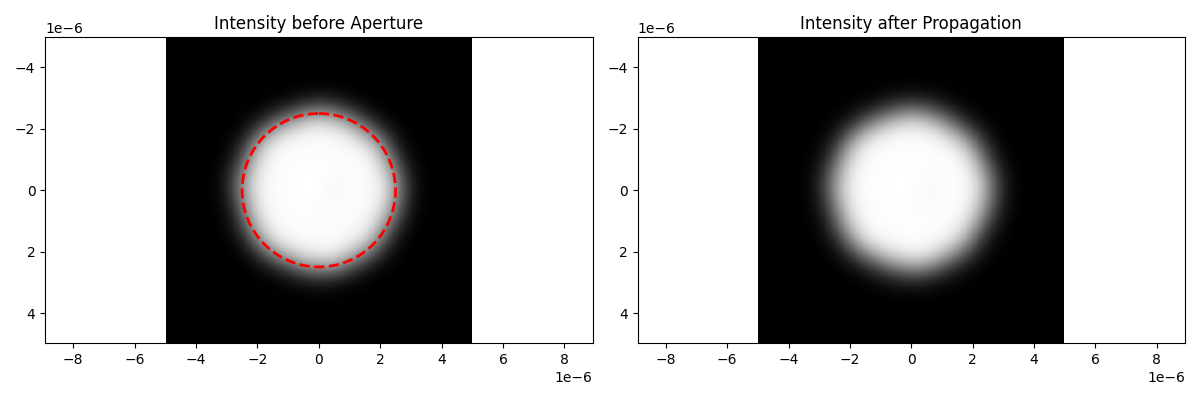

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Intensity before Aperture
axes[0].set_title('Intensity before Aperture')
axes[0].axis('equal')
circle = plt.Circle((0, 0), W / 4, color='red', fill=False, linestyle='--', linewidth=2)
axes[0].add_artist(circle)
axes[0].imshow(np.abs(E_in), cmap='gray', extent=extent)

# Intensity after Propagation
axes[1].set_title('Intensity after Propagation')
axes[1].axis('equal')
axes[1].imshow(np.abs(E_prop), cmap='gray', extent=extent)

plt.tight_layout()


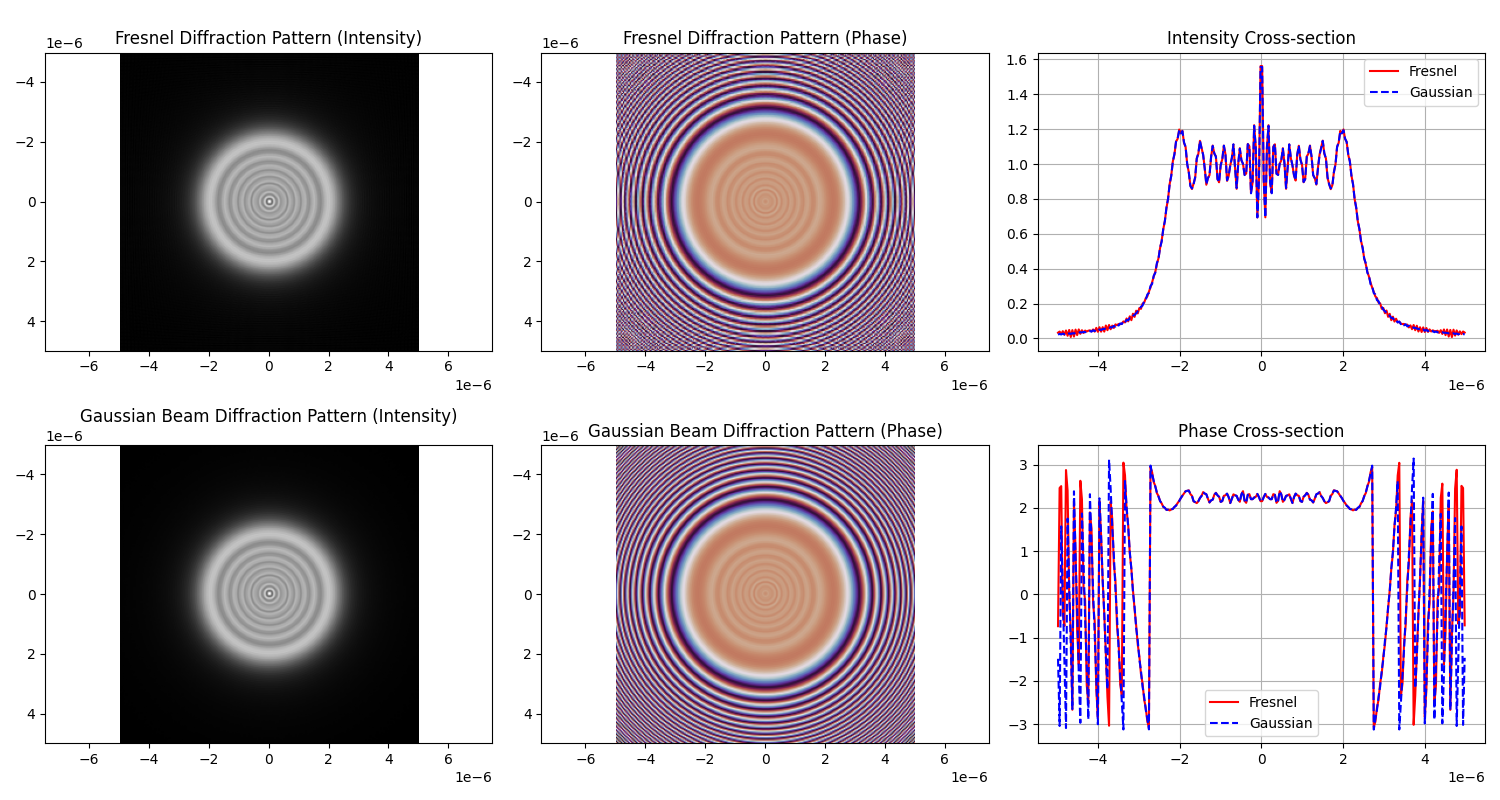

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8))

# Fresnel Diffraction Pattern - Intensity
axs[0, 0].imshow(np.abs(fresnel_diffraction_pattern), cmap='gray', extent=extent)
axs[0, 0].set_title('Fresnel Diffraction Pattern (Intensity)')
axs[0, 0].axis('equal')

# Fresnel Diffraction Pattern - Phase
axs[0, 1].imshow(np.angle(fresnel_diffraction_pattern), cmap='twilight', extent=extent)
axs[0, 1].set_title('Fresnel Diffraction Pattern (Phase)')
axs[0, 1].axis('equal')

# Gaussian Beam Diffraction Pattern - Intensity
axs[1, 0].imshow(np.abs(E_prop), cmap='gray', extent=extent)
axs[1, 0].set_title('Gaussian Beam Diffraction Pattern (Intensity)')
axs[1, 0].axis('equal')

# Gaussian Beam Diffraction Pattern - Phase
axs[1, 1].imshow(np.angle(E_prop), cmap='twilight', extent=extent)
axs[1, 1].set_title('Gaussian Beam Diffraction Pattern (Phase)')
axs[1, 1].axis('equal')

# Cross section - Intensity
axs[0, 2].plot(x, np.abs(fresnel_diffraction_pattern[center_idx, :]), color='red', label='Fresnel')
axs[0, 2].plot(x, np.abs(E_prop[center_idx, :]), color='blue', linestyle='--', label='Gaussian')
axs[0, 2].set_title('Intensity Cross-section')
axs[0, 2].legend()
axs[0, 2].grid(True)

# Cross section - Phase
axs[1, 2].plot(x, np.angle(fresnel_diffraction_pattern[center_idx, :]), color='red', label='Fresnel')
axs[1, 2].plot(x, np.angle(E_prop[center_idx, :]), color='blue', linestyle='--', label='Gaussian')
axs[1, 2].set_title('Phase Cross-section')
axs[1, 2].legend()
axs[1, 2].grid(True)

plt.tight_layout()